In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [9]:
data = pd.read_csv(r"C:\Users\ASUS\Downloads\Breast cancer.csv")

In [10]:
df = data.copy()
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [11]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
x_imputed = imputer.fit_transform(x_scaled)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_imputed)

In [13]:
explained_variance = pca.explained_variance_ratio_
print(f"PC1 {explained_variance[0]:.4f}")
print(f"PC2 {explained_variance[1]:.4f}")

PC1 0.4351
PC2 0.1791


In [14]:
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_pca)
    wcss.append(kmeans.inertia_)

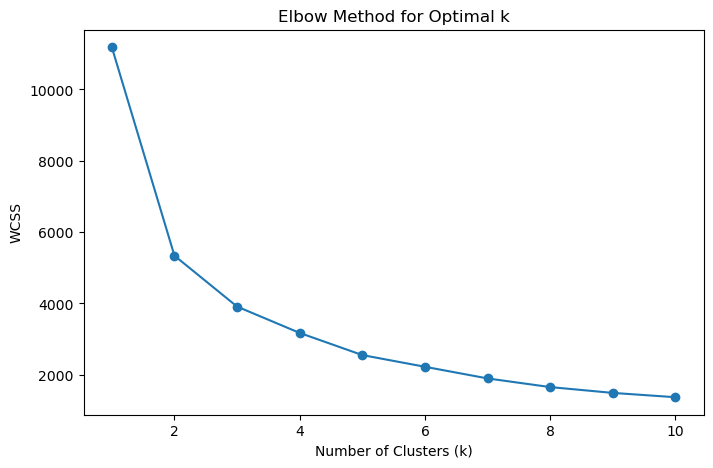

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

In [16]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_pca)

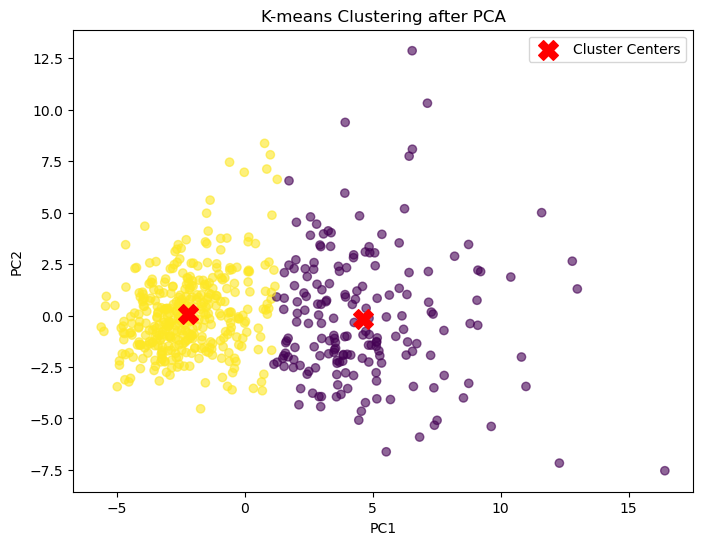

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Cluster Centers'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clustering after PCA')
plt.legend()
plt.show()